In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline

np.random.seed(2)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools

from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

sns.set(style = 'white', context = 'notebook', palette = 'deep')

In [2]:
train  = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

In [3]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [5]:
Y_train = train["label"]

# Drop 'label' column
X_train = train.drop(labels = ["label"],axis = 1) 

# free some space
del train 

Y_train.value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

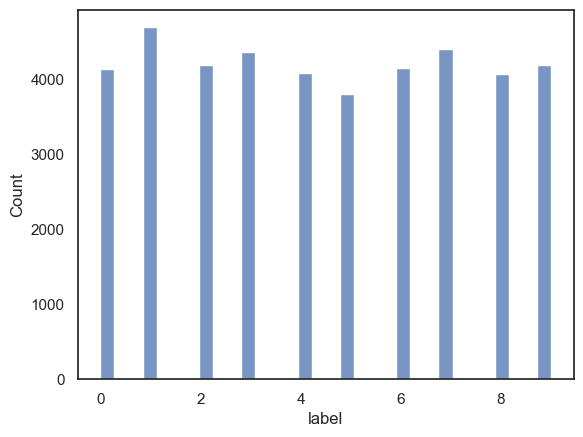

In [6]:
g = sns.histplot(Y_train)
plt.show

In [7]:
X_train.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object

In [8]:
test.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object

In [9]:
X_train = X_train / 255.0
test = test / 255.0

In [10]:
X_train = np.asarray(X_train).reshape(-1,28,28,1)
test  = np.array(test).reshape(-1,28,28,1)

In [11]:
Y_train = to_categorical(Y_train, num_classes = 10)

In [12]:
random_seed = 2

In [13]:
X_train, X_val, Y_train, Y_val  = train_test_split(X_train, Y_train, test_size = 0.1, random_state = random_seed)

In [14]:
model = Sequential()

In [15]:
model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu', input_shape = (28,28,1)))
model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

C:\Users\jhonw\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
optimizer = RMSprop(learning_rate = 0.001, rho = 0.9,epsilon = 1e-07 )

In [17]:
model.compile(optimizer = optimizer, loss = "categorical_crossentropy", metrics = ['accuracy'])

In [18]:
learning_rate_reduction = ReduceLROnPlateau(monitor = 'val_accuracy',
                                          patience  = 3,
                                          verbose = 1,
                                          factor = 0.5,
                                          min_learning_rate = 0.00001)

In [19]:
epochs = 10
batch_size = 90

In [20]:
datagen = ImageDataGenerator(
         featurewise_center = False,
         samplewise_center = False,
         featurewise_std_normalization = False,
         samplewise_std_normalization = False,
         zca_whitening = False,
         rotation_range = 10,
         zoom_range = 0.1,
         width_shift_range = 0.1,
         height_shift_range = 0.1,
         horizontal_flip = False,
         vertical_flip = False)

datagen.fit(X_train)

In [21]:
history = model.fit(datagen.flow(X_train, Y_train, batch_size = batch_size), epochs = epochs, validation_data = (X_val, Y_val),
                             verbose = 2, steps_per_epoch = X_train.shape[0] // batch_size,
                             callbacks = [learning_rate_reduction])

Epoch 1/10
420/420 - 43s - 101ms/step - accuracy: 0.8458 - loss: 0.4695 - val_accuracy: 0.9774 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 2/10
420/420 - 43s - 103ms/step - accuracy: 0.9599 - loss: 0.1361 - val_accuracy: 0.9874 - val_loss: 0.0418 - learning_rate: 0.0010
Epoch 3/10
420/420 - 42s - 100ms/step - accuracy: 0.9712 - loss: 0.0976 - val_accuracy: 0.9900 - val_loss: 0.0332 - learning_rate: 0.0010
Epoch 4/10
420/420 - 41s - 97ms/step - accuracy: 0.9768 - loss: 0.0793 - val_accuracy: 0.9881 - val_loss: 0.0421 - learning_rate: 0.0010
Epoch 5/10
420/420 - 40s - 96ms/step - accuracy: 0.9797 - loss: 0.0682 - val_accuracy: 0.9924 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 6/10
420/420 - 40s - 96ms/step - accuracy: 0.9806 - loss: 0.0661 - val_accuracy: 0.9931 - val_loss: 0.0310 - learning_rate: 0.0010
Epoch 7/10
420/420 - 45s - 107ms/step - accuracy: 0.9825 - loss: 0.0603 - val_accuracy: 0.9931 - val_loss: 0.0248 - learning_rate: 0.0010
Epoch 8/10
420/420 - 41s - 97ms/step 

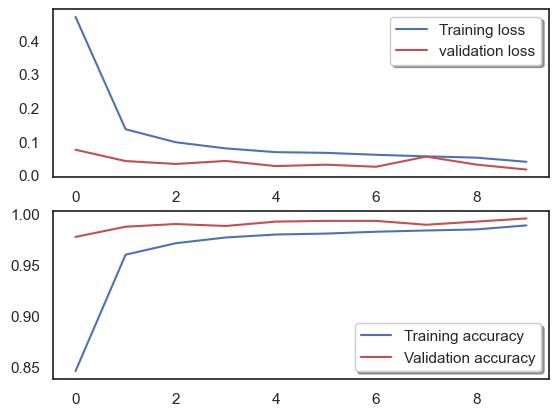

In [25]:
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color = 'b', label = "Training loss")
ax[0].plot(history.history['val_loss'],color = 'r', label = "validation loss")
legend = ax[0].legend(loc = 'best', shadow = True)

ax[1].plot(history.history['accuracy'], color = 'b', label = "Training accuracy")
ax[1].plot(history.history['val_accuracy'], color = 'r',label = "Validation accuracy")

legends = ax[1].legend(loc = 'best', shadow = True)

In [32]:
def plot_confusion_matrix(cm, classes, normalize = False, title = 'Confusion Matrix', cmap = plt.cm.Blues):
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

    thresh = cm.max() /2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                horizontalalignment = 'center',
                color = 'white' if cm[i, j] > thresh else 'black')

        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')


132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


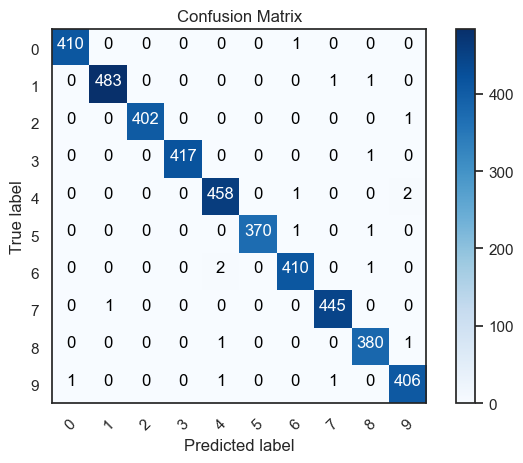

In [33]:
Y_pred = model.predict(X_val)
Y_pred_classes  = np.argmax(Y_pred, axis = 1)
Y_true = np.argmax(Y_val, axis = 1)
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
plot_confusion_matrix(confusion_mtx, classes = range(10))

In [62]:
errors = (Y_pred_classes - Y_true != 0)

Y_pred_classes_errors = Y_pred_classes[errors]
Y_pred_errors = Y_pred[errors]
Y_true_errors = Y_true[errors]
X_val_errors = X_val[errors]

def display_errors(errors_index, img_errors, pred_errors, obs_errors):
    n = 0
    nrows = 2
    ncols = 3
    fig, ax = plt.subplots(nrows, ncols, sharex = True, sharey = True)
    for row in range(nrows):
        for col in range(ncols):
            error = errors_index[n]
            ax[row, col].imshow((img_errors[error]).reshape((28,28)))
            ax[row, col].set_title("Predicted label :{}\nTrue label :{}"
        .format(pred_errors[error], obs_errors[error]))
            n += 1
    

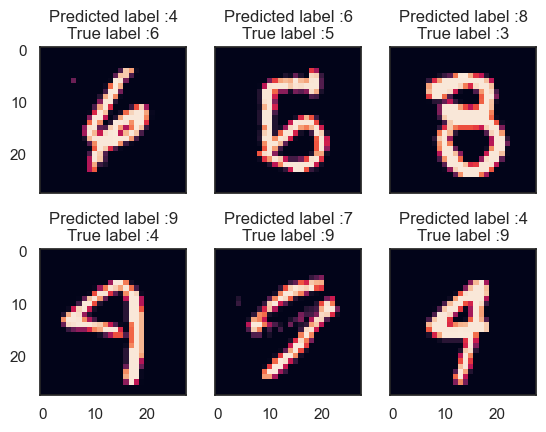

In [64]:
Y_pred_errors_prob = np.max(Y_pred_errors, axis = 1)
true_prob_errors = np.diagonal(np.take(Y_pred_errors, Y_true_errors, axis = 1))
delta_pred_true_errors = Y_pred_errors_prob - true_prob_errors
sorted_dela_errors = np.argsort(delta_pred_true_errors)
most_important_errors = sorted_dela_errors[-6:]
display_errors(most_important_errors, X_val_errors, Y_pred_classes_errors, Y_true_errors)

In [67]:
results = model.predict(test)
results = np.argmax(results, axis = 1)
results = pd.Series(results, name = 'Label')

875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step


In [68]:
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),results],axis = 1)

submission.to_csv("cnn_mnist_datagen.csv",index=False)

In [69]:
import pandas as pd
check_submission = pd.read_csv("cnn_mnist_datagen.csv")
check_submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
